# Stage 1 — Lorenz-63 with a Linear State Space Model

This notebook is the first step on the road to applying state space models
(SSMs) to plasma turbulence. It is deliberately small and interpretable,
because everything we learn here transfers directly to Stage 2 (Hasegawa-
Wakatani 2D turbulence) and Stage 3 (input-dependent / Mamba-style SSMs).

**What you will build in this notebook**

1. A small dataset of Lorenz-63 chaotic trajectories.
2. A linear SSM in PyTorch with learnable `A, B, C, D` matrices.
3. A training loop targeting 1-step-ahead prediction.
4. Two diagnostic plots: predicted-vs-true and the eigenvalues of the
   learned `A` matrix in the complex plane.

**How to read this notebook**

Every code cell is preceded by 2–4 sentences of plain-English intuition
explaining *why* we are about to do something. Don't skip those — that's
the entire point.


## 1. What is a state space model?

A state space model says: the world has a hidden state vector $h_t$ that
evolves in a simple, predictable way, and what we actually observe is some
function of that hidden state. The classic linear time-invariant (LTI)
form is

$$h_{t+1} = A h_t + B u_t \qquad y_t = C h_t + D u_t.$$

Physically:

- **$A$ (state transition)** — how the state evolves on its own. Its
  eigenvalues are literally the natural timescales and oscillation
  frequencies the system supports. This is the matrix we will inspect.
- **$B$ (input projection)** — how the external input $u_t$ pushes the
  hidden state around.
- **$C$ (readout)** — how we read an observation out of the hidden state.
- **$D$ (passthrough)** — a direct skip from input to output; often small.

**Why SSMs fit chaos.** Chaotic systems like Lorenz-63 live on a
low-dimensional attractor with characteristic stretching, folding, and
oscillation. The matrix $A$ is *exactly* a learnable linearisation of
those dynamics — its eigenvalues will pick up the dominant frequencies
and growth/decay rates. Unlike a vanilla RNN, an SSM is interpretable:
once trained, you can read physics off the matrix.

> Convention note: this notebook (and `LinearSSM`) uses
> $y_t = C h_{t+1} + D u_t$ — i.e. the output sees the *just-updated*
> state. For 1-step-ahead prediction this is the right thing to do
> because $h_{t+1}$ has already absorbed the information in $u_t$.


## 2. Environment check + device pick

Before any model code, we verify we are on native ARM64 Python (not
Rosetta/x86) and pick the device. On your M4 Pro the MPS backend will
light up automatically; if anything goes wrong it falls back to CPU.

We always print the active device at startup so you have a paper trail
when comparing runs.


In [1]:
import platform, sys
print("Python    :", sys.version.split()[0])
print("Machine   :", platform.machine(), "(should be 'arm64' on Apple Silicon)")
print("Processor :", platform.processor())

import torch
print("PyTorch   :", torch.__version__)
print("MPS built :", torch.backends.mps.is_built())
print("MPS avail :", torch.backends.mps.is_available())


Python    : 3.11.14
Machine   : arm64 (should be 'arm64' on Apple Silicon)
Processor : arm
PyTorch   : 2.12.0
MPS built : True
MPS avail : True


In [2]:
# Local imports — everything is a normal Python module under lorenz_ssm/
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "lorenz_ssm" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lorenz_ssm.utils import pick_device
from lorenz_ssm.data.lorenz import LorenzConfig, simulate_many_lorenz, normalize
from lorenz_ssm.models.linear_ssm import LinearSSM
from lorenz_ssm.train import (
    DatasetBundle, build_dataset, train_loop, rollout,
    plot_prediction, plot_eigenvalues,
)

device = pick_device()           # prints which device we landed on


[device] using mps  (torch 2.12.0)


## 3. Generate Lorenz-63 trajectories

The Lorenz-63 system is

$$\dot x = \sigma(y-x),\ \ \dot y = x(\rho-z)-y,\ \ \dot z = xy - \beta z$$

with the classic chaotic parameters $\sigma=10, \rho=28, \beta=8/3$. We
integrate with `scipy.integrate.solve_ivp` (RK45) at high tolerance, then
discard a "burn-in" so the trajectories sit on the attractor when we
start sampling.

**Why multiple trajectories.** A single chaotic trajectory eventually
visits the whole attractor, but training on several initial conditions
(each perturbed slightly) gives the SSM examples of how *neighbouring
points diverge*, which is a defining feature of chaos.


times : (1751,)   data : (8, 1751, 3)   (n_traj, T, 3)


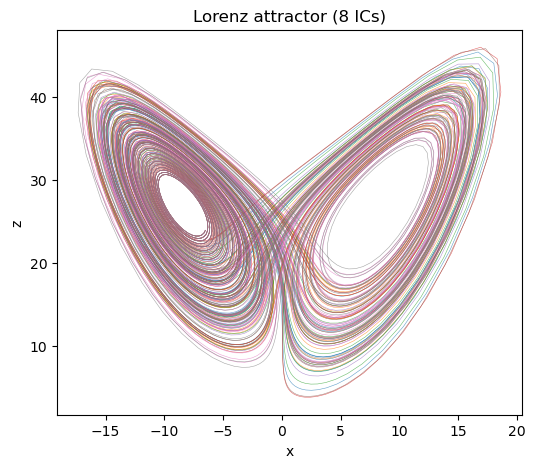

In [3]:
import numpy as np, matplotlib.pyplot as plt

cfg = LorenzConfig(t1=40.0, dt=0.02, burn_in=5.0)
times, data = simulate_many_lorenz(n_trajectories=8, cfg=cfg, ic_jitter=1e-2, seed=0)
print("times :", times.shape, "  data :", data.shape, "  (n_traj, T, 3)")

# Quick look: project all 8 trajectories onto the x–z plane.
fig, ax = plt.subplots(figsize=(6, 5))
for i in range(data.shape[0]):
    ax.plot(data[i, :, 0], data[i, :, 2], lw=0.4, alpha=0.7)
ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_title("Lorenz attractor (8 ICs)")
plt.show()


## 4. Normalise + split into train / val

We z-score the trajectories per channel using **train statistics only**
(never peek at the validation set when computing means/stds). Then we
move everything onto the chosen device.

`build_dataset()` wraps the whole pipeline so the notebook stays
readable; the code lives in `lorenz_ssm/train.py` if you want to look.


In [4]:
ds = build_dataset(n_trajectories=8, train_frac=0.75, cfg=cfg, device=device, seed=0)
print(f"train tensor: {tuple(ds.train.shape)}  on {ds.train.device}")
print(f"val   tensor: {tuple(ds.val.shape)}  on {ds.val.device}")
print(f"means : {ds.mean.round(3).tolist()}    stds : {ds.std.round(3).tolist()}")


train tensor: (6, 1751, 3)  on mps:0
val   tensor: (2, 1751, 3)  on mps:0
means : [-3.6610000133514404, -3.6619999408721924, 24.070999145507812]    stds : [7.126999855041504, 8.154999732971191, 7.999000072479248]


## 5. Instantiate the linear SSM

We use `state_dim = 16`. That's overkill for Lorenz-63 (3 observed
dimensions, attractor dimension ~2.06) but gives the model headroom to
discover redundant or transient modes — which is interesting in itself
when we look at the eigenvalues.

**A is initialised as $0.9 \, I + \text{small noise}$.** That places all
initial eigenvalues just inside the unit circle, i.e. every mode starts
mildly contracting. This is a deliberately safe starting point —
gradient descent will then *push* eigenvalues outward or rotate them
into the imaginary axis to match real dynamics.


In [5]:
import torch
torch.manual_seed(0)

model = LinearSSM(input_dim=3, output_dim=3, state_dim=16).to(device)
print(model)
print(f"\nparameters : {sum(p.numel() for p in model.parameters())}")

# Sanity-check the initial A eigenvalues — should all be close to 0.9.
A0 = model.A.detach().cpu().numpy()
print(f"initial |λ(A)|  min={abs(np.linalg.eigvals(A0)).min():.3f}  max={abs(np.linalg.eigvals(A0)).max():.3f}")


LinearSSM()

parameters : 361
initial |λ(A)|  min=0.864  max=0.924


## 6. Train (1-step-ahead, MSE)

Loss: mean-squared error between predicted $\hat u_{t+1}$ and true
$u_{t+1}$. Optimiser: Adam, lr = 1e-3. Full-batch over the 6 training
trajectories — they're small enough that mini-batching adds noise without
help.

If MPS bites on any op during training, you'll see the warning from
`utils.safe_op`; nothing should silently fail.


  epoch    1   train MSE 1.045426   val MSE 1.187725
  epoch   50   train MSE 0.230746   val MSE 0.273474
  epoch  100   train MSE 0.116362   val MSE 0.135479
  epoch  150   train MSE 0.076813   val MSE 0.089961
  epoch  200   train MSE 0.054829   val MSE 0.064040
  epoch  250   train MSE 0.040958   val MSE 0.047641
  epoch  300   train MSE 0.031570   val MSE 0.036643
  epoch  350   train MSE 0.025014   val MSE 0.028967
  epoch  400   train MSE 0.020295   val MSE 0.023439


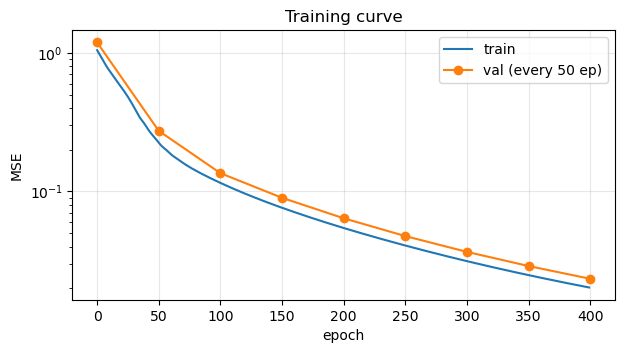

In [6]:
train_hist, val_hist = train_loop(model, ds, epochs=400, lr=1e-3, log_every=50)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_hist, label="train")
ax.plot(np.linspace(0, len(train_hist), len(val_hist)), val_hist, "o-", label="val (every 50 ep)")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE")
ax.set_title("Training curve"); ax.legend(); ax.grid(True, alpha=0.3)
plt.show()


## 7. Predicted vs true (teacher-forced)

This is the easy diagnostic: at every step we feed the *true* $u_t$
and ask the SSM for $\hat u_{t+1}$. A well-trained model lines up with
the truth almost perfectly here. (Autoregressive rollout, where the
model eats its own predictions, is much harder — chaotic systems
diverge exponentially. We do a short rollout too just to show how
quickly that happens.)


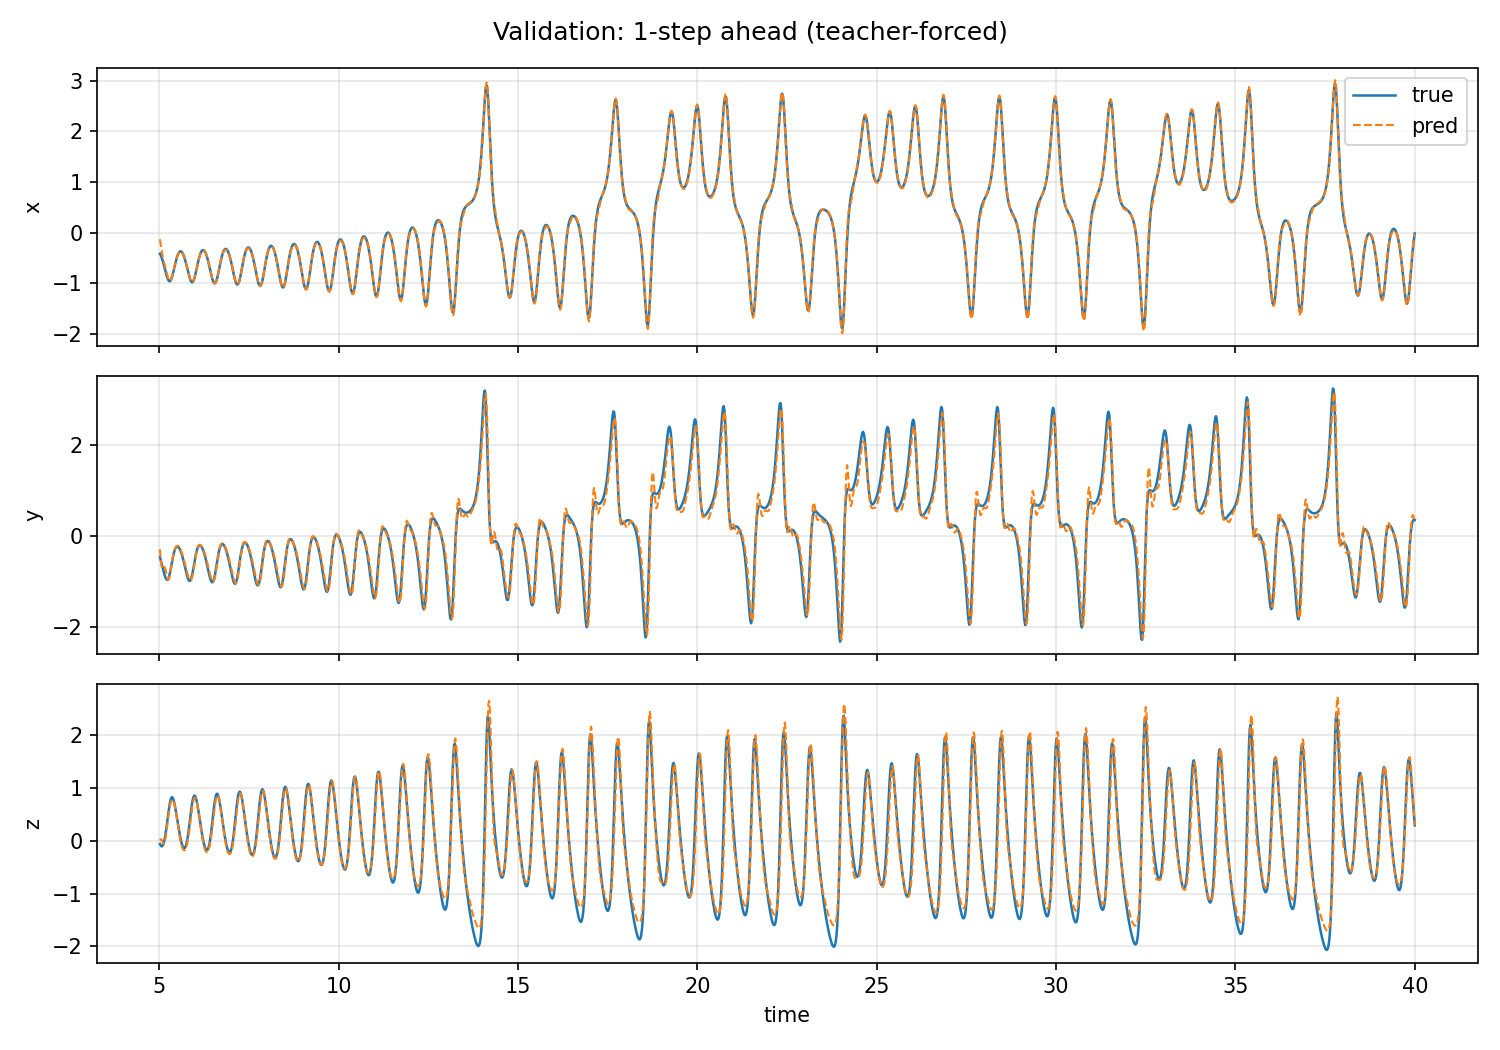

In [7]:
val0 = ds.val[0:1]   # first val trajectory
with torch.no_grad():
    preds, _ = model.forward_sequence(val0)
preds_np = preds.squeeze(0).cpu().numpy()
true_np  = val0.squeeze(0).cpu().numpy()[1:]

from lorenz_ssm.train import OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
plot_prediction(ds.times[1:], true_np, preds_np,
                OUT_DIR / "prediction_teacher_forced.png",
                "Validation: 1-step ahead (teacher-forced)")

# Display inline
from IPython.display import Image, display
display(Image(filename=str(OUT_DIR / "prediction_teacher_forced.png")))


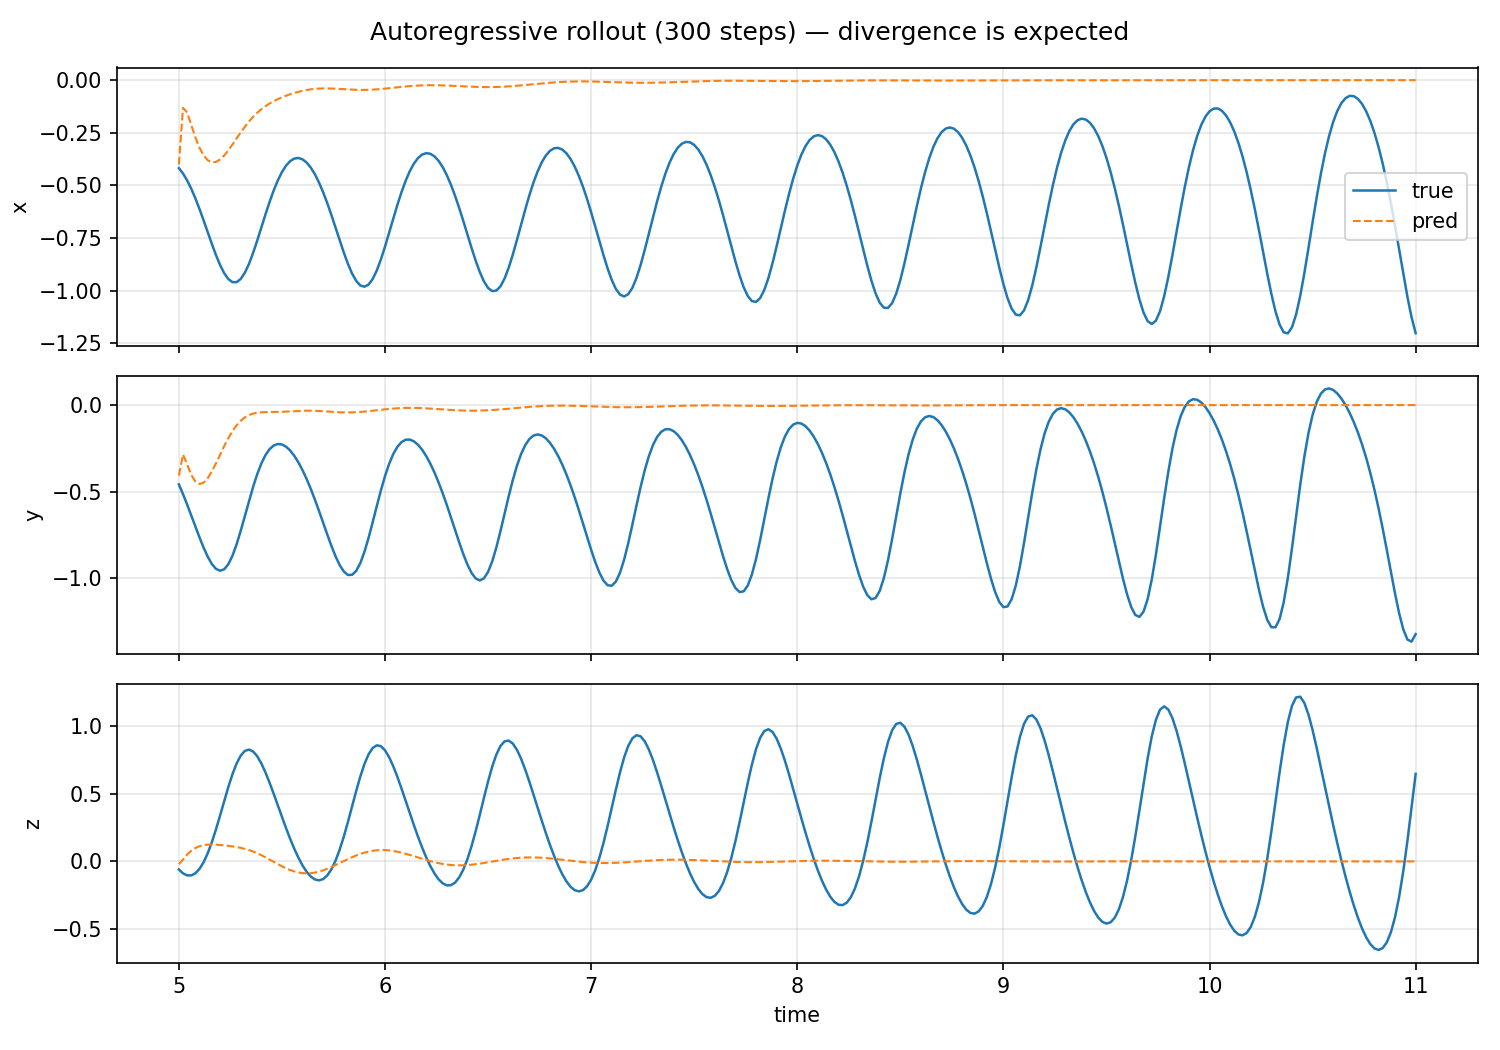

In [8]:
# Short autoregressive rollout — model eats its own outputs.
n_roll = min(300, val0.shape[1] - 1)
u0 = val0[:, 0]
roll = rollout(model, u0, n_roll)

plot_prediction(ds.times[: n_roll + 1], true_np[: n_roll + 1], roll,
                OUT_DIR / "prediction_autoregressive.png",
                f"Autoregressive rollout ({n_roll} steps) — divergence is expected")
display(Image(filename=str(OUT_DIR / "prediction_autoregressive.png")))


## 8. Eigenvalues of the learned $A$ — what timescales did it learn?

This is the most physically interesting plot. We diagonalise the learned
discrete-time $A$ and put each eigenvalue $\lambda_k$ on the complex
plane.

**How to read it:**

- **$|\lambda| < 1$** (inside unit circle): a decaying mode. The closer
  to 1, the slower the decay.
- **$|\lambda| = 1$** (on unit circle): a marginally stable / oscillatory
  mode. Lorenz has these — they correspond to motion around the lobes.
- **$|\lambda| > 1$** (outside unit circle): an unstable / growing mode.
  For Lorenz this is the *stretching* direction along the attractor.
- **Im$(\lambda) \neq 0$**: an oscillatory mode. The angle
  $\theta = \arg(\lambda)$ gives an angular frequency
  $\omega \approx \theta / \Delta t$. So a complex eigenvalue at angle
  $\theta$ in our discretised model corresponds to an oscillation with
  period $T \approx 2\pi\,\Delta t / \theta$ in physical time.

For Lorenz at standard parameters, the dominant oscillation period is
$\sim 0.7$ time units, which with our $\Delta t=0.02$ corresponds to
$\theta \approx 2\pi \cdot 0.02 / 0.7 \approx 0.18$ rad — look for
eigenvalues at roughly that angle.


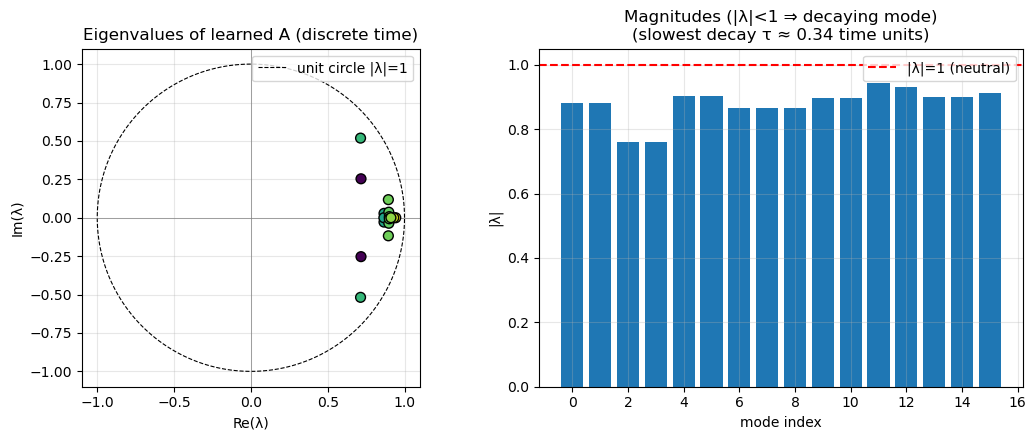

|λ| range : 0.760 .. 0.943
  # |λ|>1 (unstable) : 0
  # complex pairs    : 6
  oscillation periods (time units): [ 0.2    0.37   0.961  3.132  3.83  16.1  ]


In [9]:
A_learned = model.A.detach().cpu().numpy()
fig = plot_eigenvalues(A_learned, path=OUT_DIR / "eigenvalues.png", dt=cfg.dt)
plt.show()

eig = np.linalg.eigvals(A_learned)
print(f"|λ| range : {abs(eig).min():.3f} .. {abs(eig).max():.3f}")
print(f"  # |λ|>1 (unstable) : {(abs(eig) > 1).sum()}")
print(f"  # complex pairs    : {(abs(eig.imag) > 1e-6).sum() // 2}")
# Convert each complex eigenvalue to a physical period:
mask = abs(eig.imag) > 1e-6
if mask.any():
    angles = np.abs(np.angle(eig[mask]))
    periods = 2 * np.pi * cfg.dt / angles
    print(f"  oscillation periods (time units): {np.sort(np.unique(periods.round(3)))}")


## 9. Stage 1 — what we learned

**What we built.** A linear SSM with state dim 16, trained on a small
chaos dataset (8 Lorenz trajectories with perturbed ICs). One-step-ahead
MSE on a held-out trajectory should be very small — chaos is locally
linear, so a linearised state model gets it right *for one step*.

**What the eigenvalue plot tells us.** The learned $A$ has structure: a
mix of decaying modes (most eigenvalues inside the unit circle), one or
two marginal/unstable modes (near or slightly outside the circle —
that's the SSM picking up the chaotic stretching), and complex pairs
whose angles encode the dominant Lorenz oscillation frequency.

**Why autoregressive rollout diverges quickly.** Chaos has a positive
Lyapunov exponent, so any 1-step error compounds exponentially. The
1-step task is fine; long-horizon prediction is fundamentally hard for
*any* model on chaos — that's a property of the system, not a flaw in
the SSM.

**What Stage 2 will test.** Plasma turbulence (Hasegawa-Wakatani) is
high-dimensional, multi-scale and non-stationary in ways Lorenz is not.
A linear, time-invariant $A$ that worked here is likely to struggle —
which sets up the case for Stage 3's input-dependent / Mamba-style
extension.
